In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

In [132]:
data = pd.read_csv(r"C:\Users\Marwan\OneDrive\Desktop\6th semester\Diabetes-Prediction\Diabetes.csv")

In [133]:
data.head()

,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [134]:
print("---Information---")
data.info()

---Information---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c      1000 non-null   float64
 7   Chol       1000 non-null   float64
 8   TG         1000 non-null   float64
 9   HDL        1000 non-null   float64
 10  LDL        1000 non-null   float64
 11  VLDL       1000 non-null   float64
 12  BMI        1000 non-null   float64
 13  CLASS      1000 non-null   object 
dtypes: float64(8), int64(4), object(2)
memory usage: 109.5+ KB


In [135]:
print("---Numerical Description---")
data.describe(include=[np.number]).T

---Numerical Description---


,count,mean,std,min,25%,50%,75%,max
ID,1000.0,340.500000,2.403977e+02,1.0,125.75,300.5,550.25,800.00
No_Pation,1000.0,270551.408000,3.380758e+06,123.0,24063.75,34395.5,45384.25,75435657.00
AGE,1000.0,53.528000,8.799241e+00,20.0,51.00,55.0,59.00,79.00
Urea,1000.0,5.124743,2.935165e+00,0.5,3.70,4.6,5.70,38.90
Cr,1000.0,68.943000,5.998475e+01,6.0,48.00,60.0,73.00,800.00
HbA1c,1000.0,8.281160,2.534003e+00,0.9,6.50,8.0,10.20,16.00
Chol,1000.0,4.862820,1.301738e+00,0.0,4.00,4.8,5.60,10.30
TG,1000.0,2.349610,1.401176e+00,0.3,1.50,2.0,2.90,13.80
HDL,1000.0,1.204750,6.604136e-01,0.2,0.90,1.1,1.30,9.90
LDL,1000.0,2.609790,1.115102e+00,0.3,1.80,2.5,3.30,9.90


In [136]:
print("---Categorical Description---")
data.describe(include=[object]).T

---Categorical Description---


,count,unique,top,freq
Gender,1000,3,M,565
CLASS,1000,5,Y,840


In [137]:
data["Gender"].unique()

array(['F', 'M', 'f'], dtype=object)

In [138]:
data["CLASS"].unique()

array(['N', 'N ', 'P', 'Y', 'Y '], dtype=object)

In [139]:
# Clean and standardize the target and gender columns

data["CLASS"] = data["CLASS"].astype(str).str.strip().str.upper()
data["Gender"] = data["Gender"].astype(str).str.strip().str.upper()

# Display the unique values after cleaning
print("Distribution of CLASS labels:")
print(data["CLASS"].value_counts(dropna=False))

print("\nDistribution of Gender values:")
print(data["Gender"].value_counts(dropna=False))

Distribution of CLASS labels:
CLASS
Y    844
N    103
P     53
Name: count, dtype: int64

Distribution of Gender values:
Gender
M    565
F    435
Name: count, dtype: int64


In [140]:
data["CLASS"].unique()

array(['N', 'P', 'Y'], dtype=object)

In [141]:
data["Gender"].unique()

array(['F', 'M'], dtype=object)

In [142]:
# outlier detection and removal for numerical columns
data_numeric = data.select_dtypes(include=[np.number])
data_numeric.drop(columns=['ID',"No_Pation"], inplace=True)
data_categorical = data.select_dtypes(include=[object])

In [143]:
data_numeric

,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI
0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0
2,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
3,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0
4,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0
...,...,...,...,...,...,...,...,...,...,...
995,71,11.0,97,7.0,7.5,1.7,1.2,1.8,0.6,30.0
996,31,3.0,60,12.3,4.1,2.2,0.7,2.4,15.4,37.2
997,30,7.1,81,6.7,4.1,1.1,1.2,2.4,8.1,27.4
998,38,5.8,59,6.7,5.3,2.0,1.6,2.9,14.0,40.5


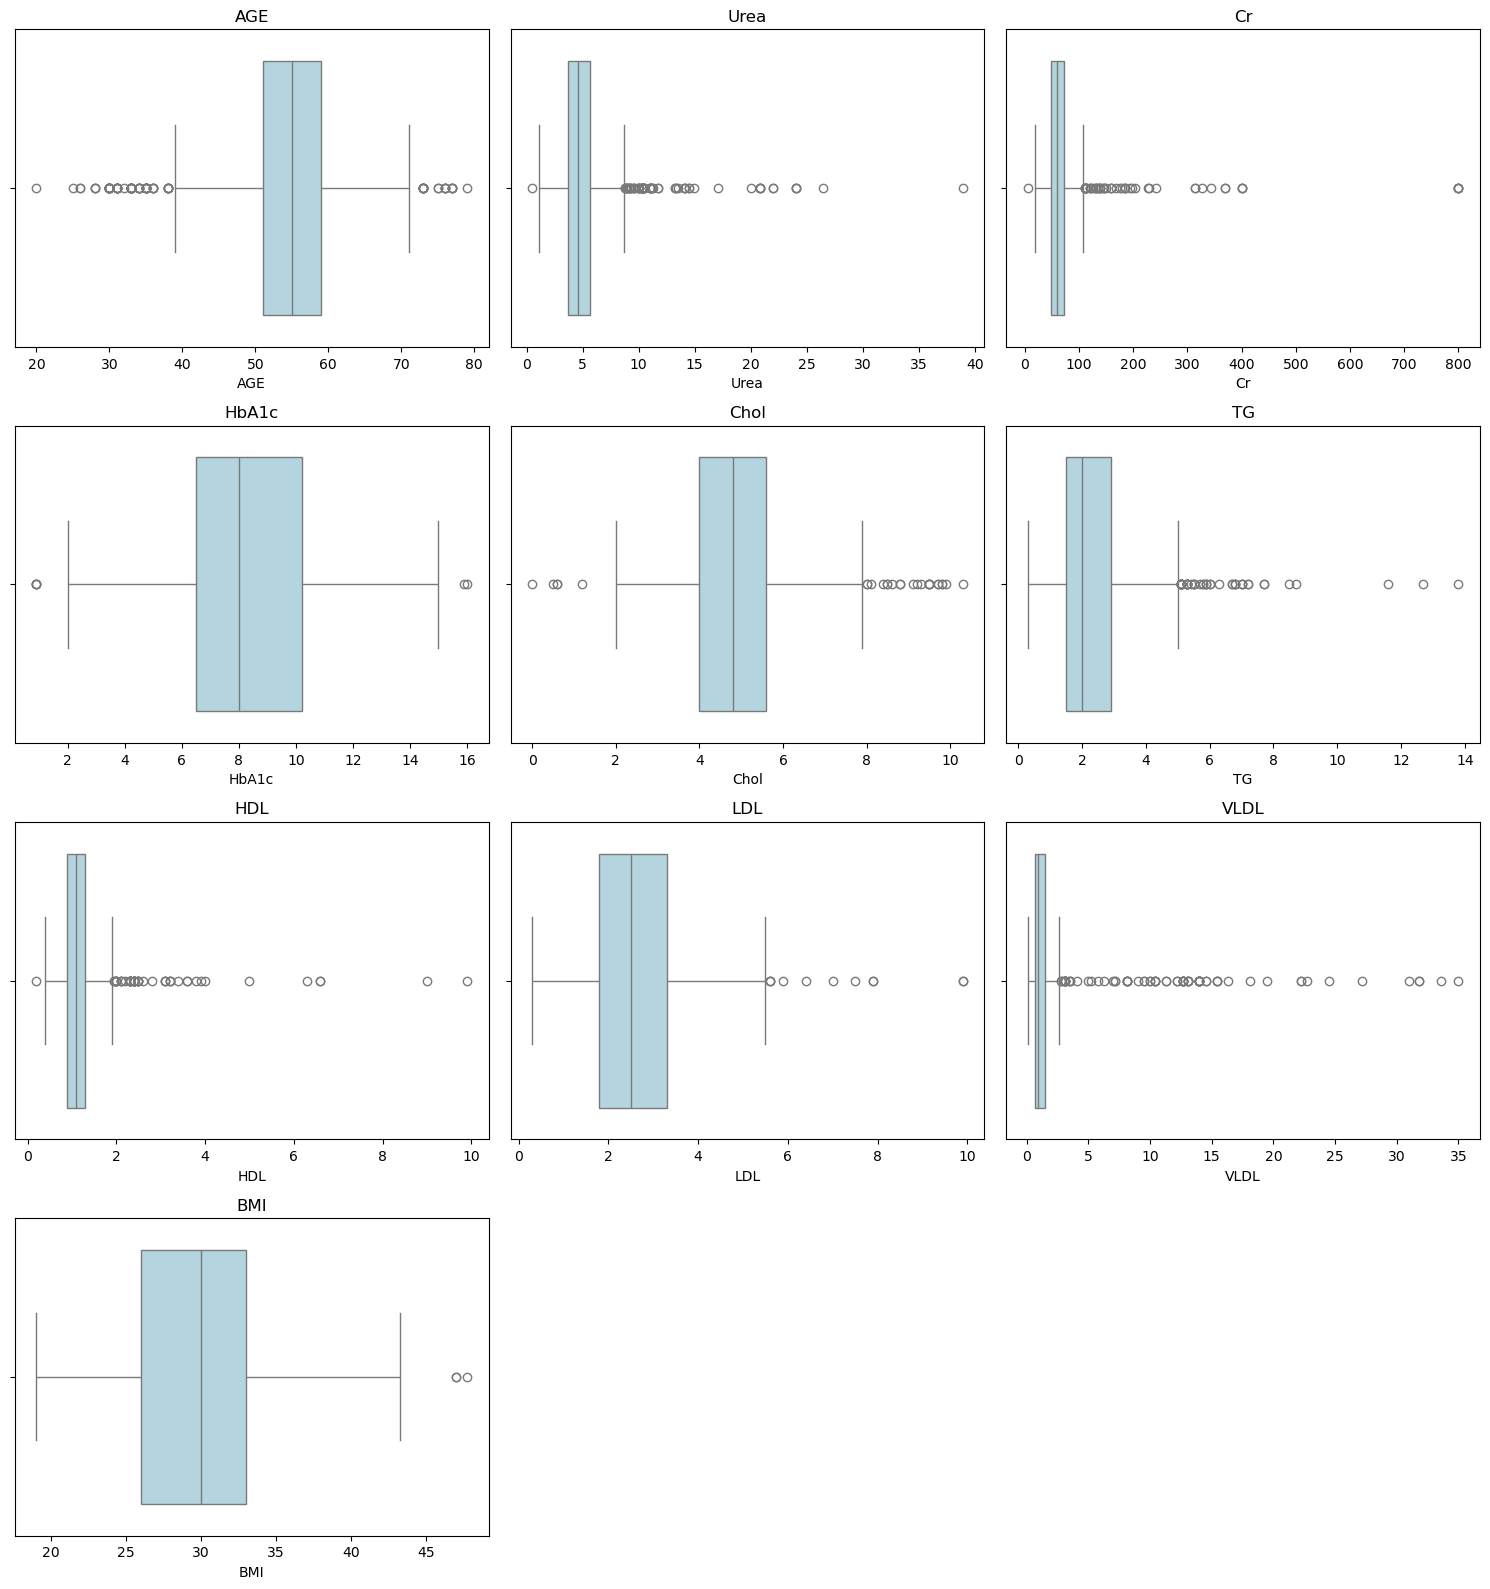

AGE: 98 outliers (9.80%)
Urea: 65 outliers (6.50%)
Cr: 52 outliers (5.20%)
HbA1c: 6 outliers (0.60%)
Chol: 27 outliers (2.70%)
TG: 55 outliers (5.50%)
HDL: 50 outliers (5.00%)
LDL: 11 outliers (1.10%)
VLDL: 74 outliers (7.40%)
BMI: 3 outliers (0.30%)


In [144]:
# Visualize numeric features with boxplots and identify outliers using the IQR method
cols = data_numeric.columns.tolist()

n = len(cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

outlier_counts = {}

for i, col in enumerate(cols):
    sns.boxplot(x=data_numeric[col], ax=axes[i], color="lightblue")
    axes[i].set_title(col)
    # IQR method
    q1 = data_numeric[col].quantile(0.25)
    q3 = data_numeric[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (data_numeric[col] < lower) | (data_numeric[col] > upper)
    outlier_counts[col] = int(mask.sum())

# hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Print number (and percentage) of outliers per feature
for col, cnt in outlier_counts.items():
    print(f"{col}: {cnt} outliers ({cnt/len(data_numeric):.2%})")

Outlier detection (DBSCAN)

In [145]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Numerical features used for clustering
dbscan_features = data[
    ["AGE", "Urea", "Cr", "HbA1c", "Chol",
     "TG", "HDL", "LDL", "VLDL", "BMI"]
].copy()

# Scale the data before applying DBSCAN
feature_scaler = StandardScaler()
scaled_data = feature_scaler.fit_transform(dbscan_features)

# Train the DBSCAN model
dbscan_model = DBSCAN(
    eps=3,
    min_samples=5
)

cluster_labels = dbscan_model.fit_predict(scaled_data)

# Detect observations labeled as noise (-1)
noise_points = cluster_labels == -1
detected_outliers = data.loc[noise_points]

# Display outlier information
print("DBSCAN Outlier Detection")
print("-" * 35)

print(f"Total Outliers     : {noise_points.sum()}")
print(f"Outlier Percentage : {(noise_points.sum() / len(data)) * 100:.2f}%")

print("\nIndices of Detected Outliers:")
print(detected_outliers.index.tolist())

print("\nOutlier Records:")
print(detected_outliers)

DBSCAN Outlier Detection
-----------------------------------
Total Outliers     : 32
Outlier Percentage : 3.20%

Indices of Detected Outliers:
[20, 95, 99, 151, 208, 212, 273, 277, 283, 284, 412, 415, 447, 526, 533, 565, 589, 590, 592, 662, 667, 709, 752, 776, 807, 814, 816, 846, 860, 884, 892, 896]

Outlier Records:
      ID  No_Pation Gender  AGE   Urea   Cr  HbA1c  Chol    TG   HDL  LDL  \
20    64      34240      F   49  13.50  175    5.1   0.5   1.9  1.30  2.8   
95   171      45434      M   40  22.00  159    5.4   3.1   1.6  1.10  1.3   
99   186     454316      M   77   5.00  106    5.4   0.0   2.8  0.80  1.8   
151  133      45366      M   30  17.10  344    6.0   4.9   1.6  1.70  2.5   
208  161      24025      M   57   4.60  370    6.8   4.0   6.0  2.50  3.5   
212  534      34305      M   57   4.60  370    6.8   6.1   6.0  2.50  3.5   
273    1      34325      M   58  20.80  800    9.1   6.6   2.9  1.10  4.3   
277  251      24055      M   73   4.30   67   10.3   4.2   1.9  1

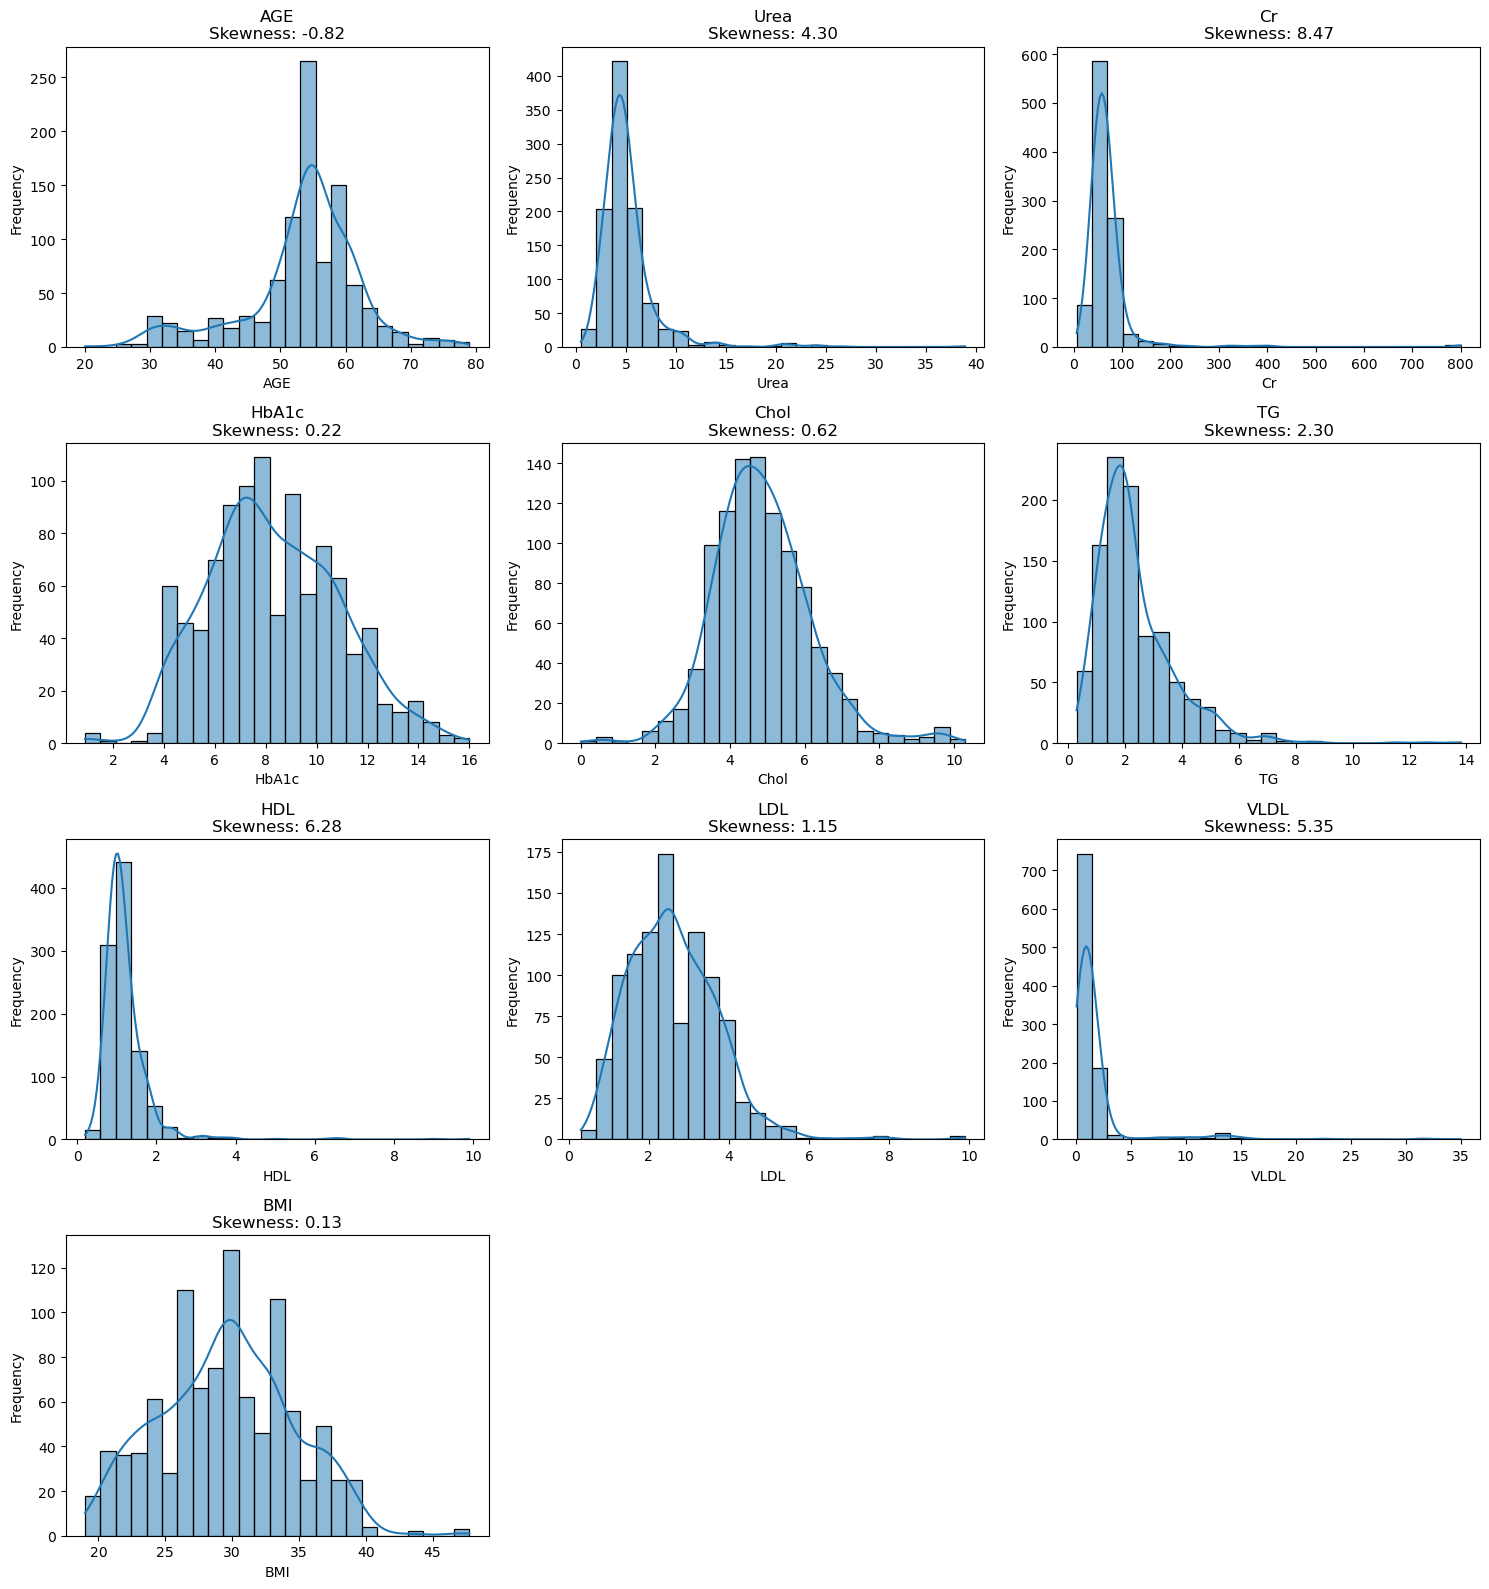

In [146]:
# Plot the distribution of all numerical features
numeric_columns = list(data_numeric.columns)

plots_per_row = 3
total_plots = len(numeric_columns)
rows = (total_plots + plots_per_row - 1) // plots_per_row

fig, ax = plt.subplots(rows, plots_per_row, figsize=(15, 4 * rows))
ax = ax.ravel()

for index, feature in enumerate(numeric_columns):
    sns.histplot(
        data=data_numeric,
        x=feature,
        bins=25,
        kde=True,
        ax=ax[index]
    )

    ax[index].set_title(f"{feature}\nSkewness: {data_numeric[feature].skew():.2f}")
    ax[index].set_xlabel(feature)
    ax[index].set_ylabel("Frequency")

# Remove any extra empty plots
for empty_plot in ax[total_plots:]:
    fig.delaxes(empty_plot)

plt.tight_layout()
plt.show()

C:\Users\Marwan\AppData\Local\Temp\ipykernel_22468\4158217436.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


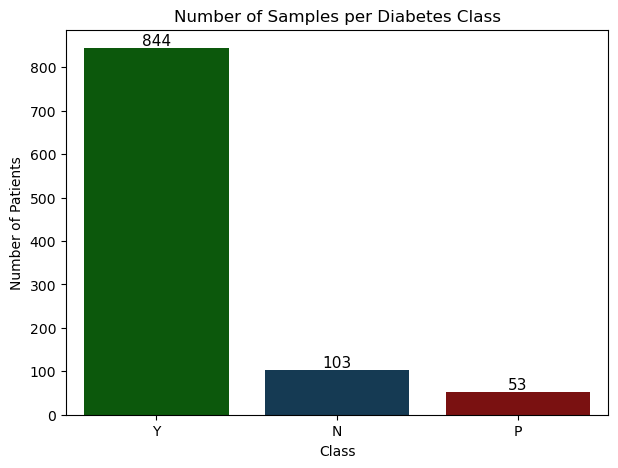

In [147]:
# Bar chart showing the number of samples in each class
class_distribution = data["CLASS"].value_counts()

labels = class_distribution.index
counts = class_distribution.values

color_map = { "N": "#0B3C5D", "P": "#8B0000", "Y": "#006400"  }

my_colors = [color_map[label] for label in labels]

plt.figure(figsize=(7,5))

sns.barplot(
    x=labels,
    y=counts,
    palette=my_colors
)

plt.title("Number of Samples per Diabetes Class")
plt.xlabel("Class")
plt.ylabel("Number of Patients")

for i, value in enumerate(counts):
    plt.text(i, value + 5, str(value), ha="center", fontsize=11)

plt.show()

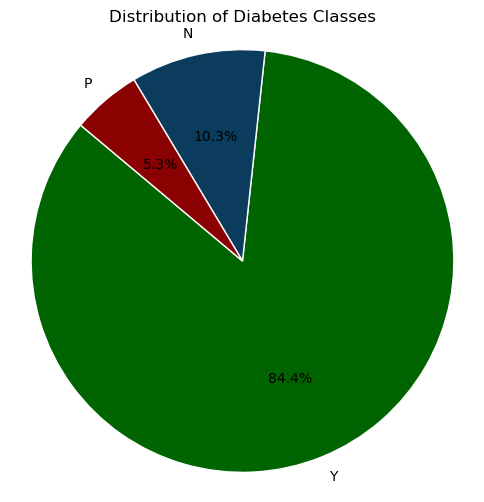

In [148]:
# Pie chart showing the percentage of each class
plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=labels,
    colors=my_colors,
    autopct="%.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white"}
)

plt.title("Distribution of Diabetes Classes")
plt.axis("equal")

plt.show()

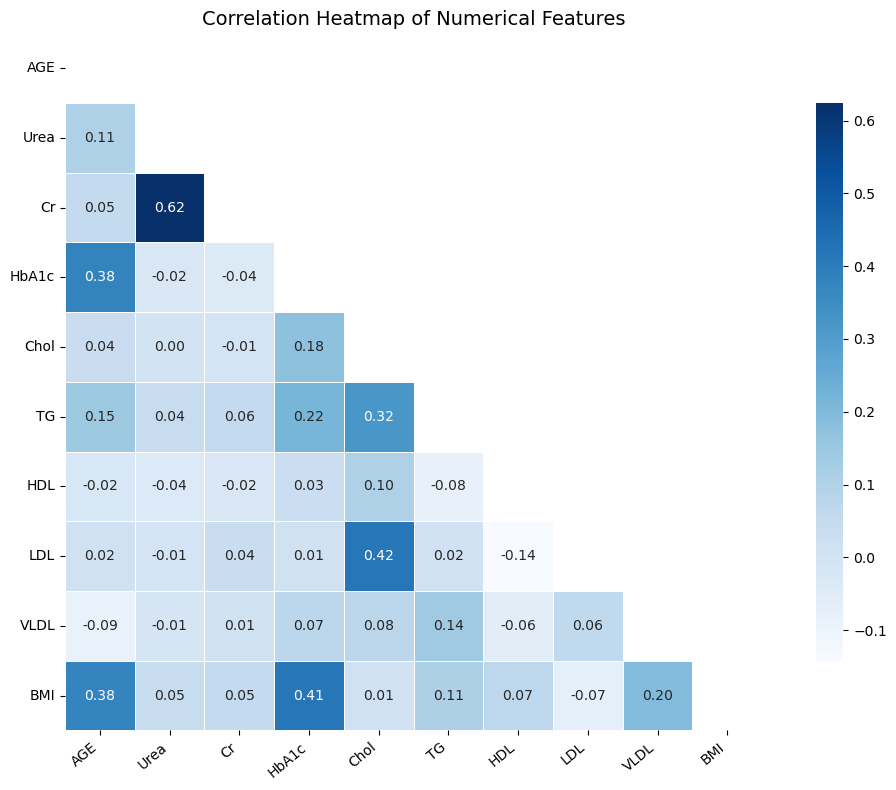

In [149]:
# Display the correlation matrix for numerical features

plt.figure(figsize=(11, 8))
corr = data_numeric.corr()
upper_triangle = np.triu(np.ones(corr.shape, dtype=bool))

sns.heatmap(
    corr,
    mask=upper_triangle,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.4,
    square=True,
    cbar=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.xticks(rotation=40, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

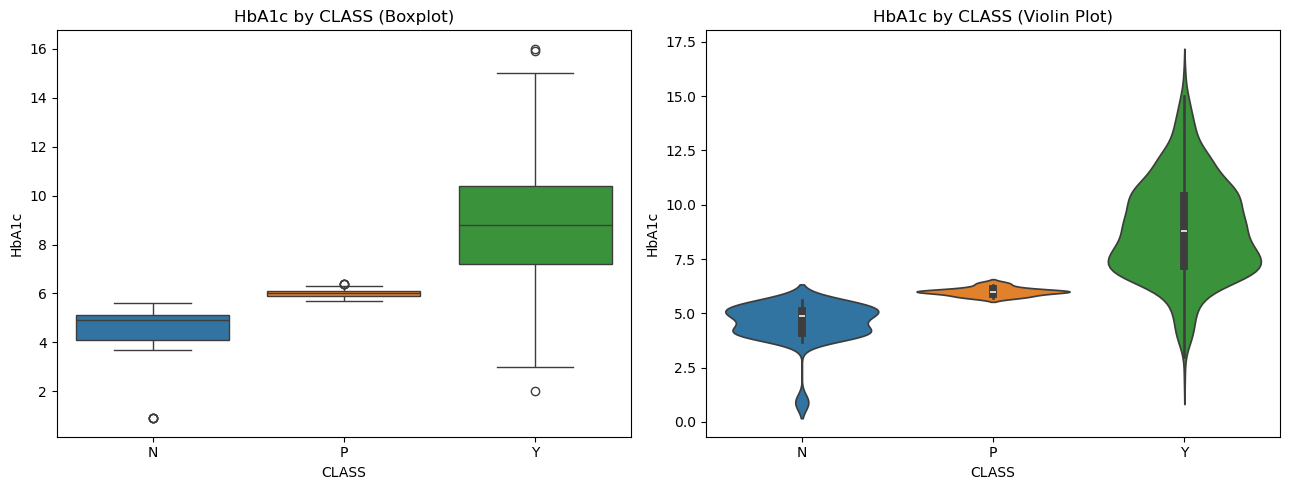

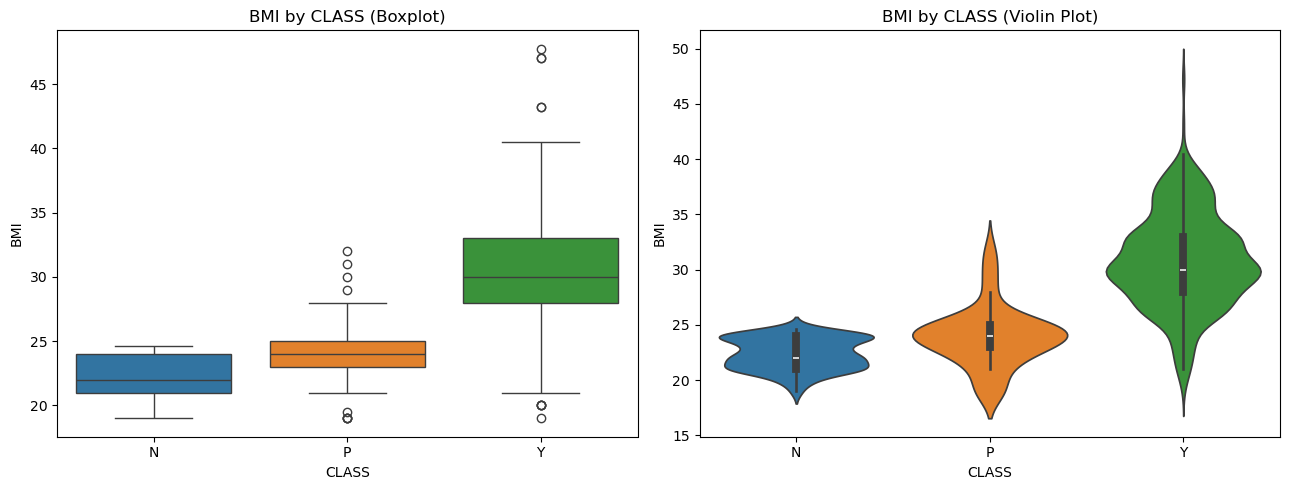

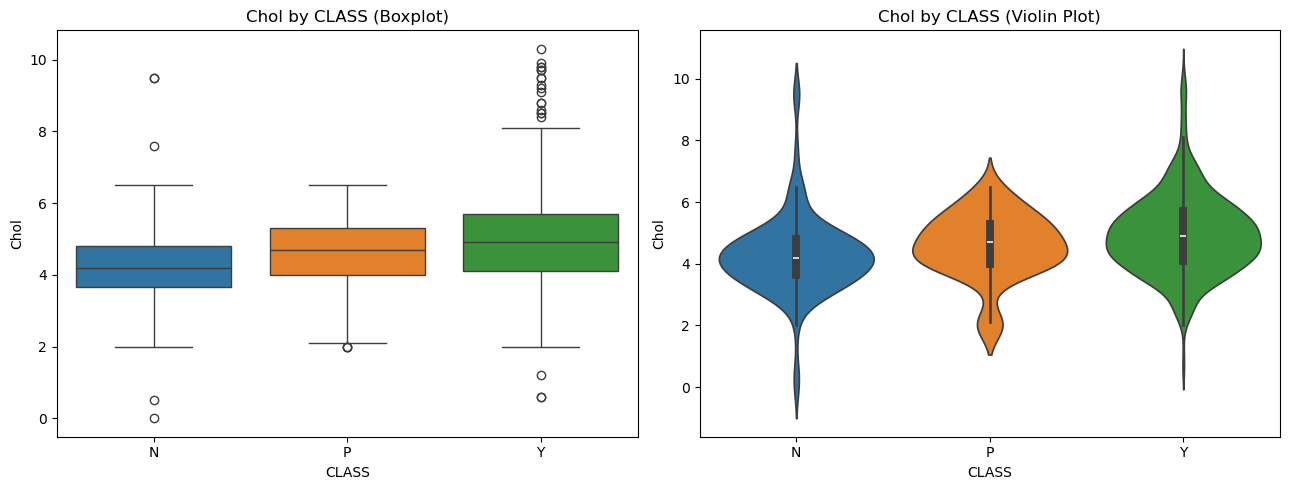

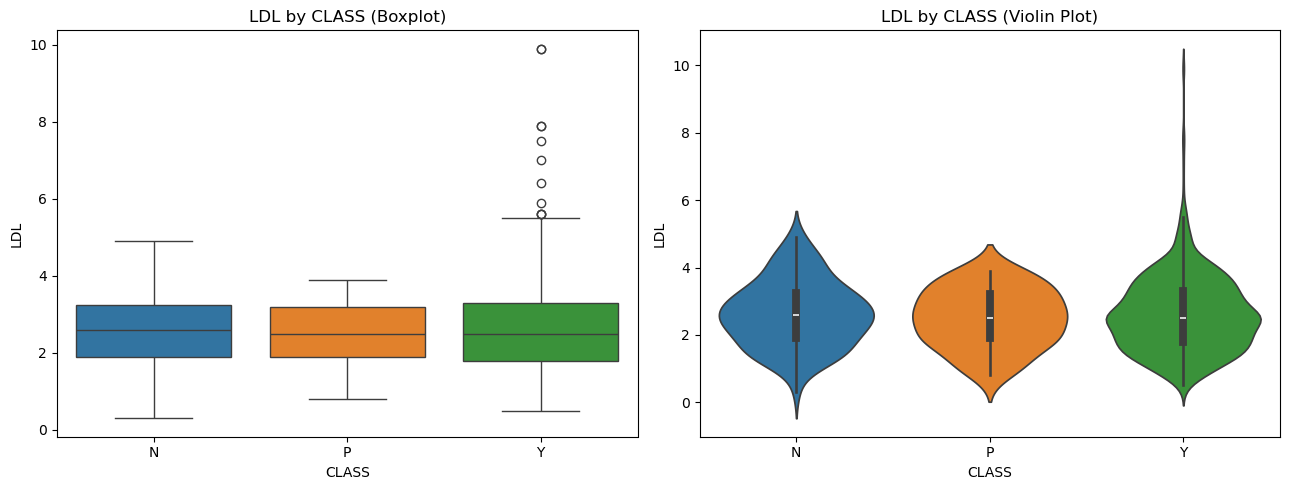

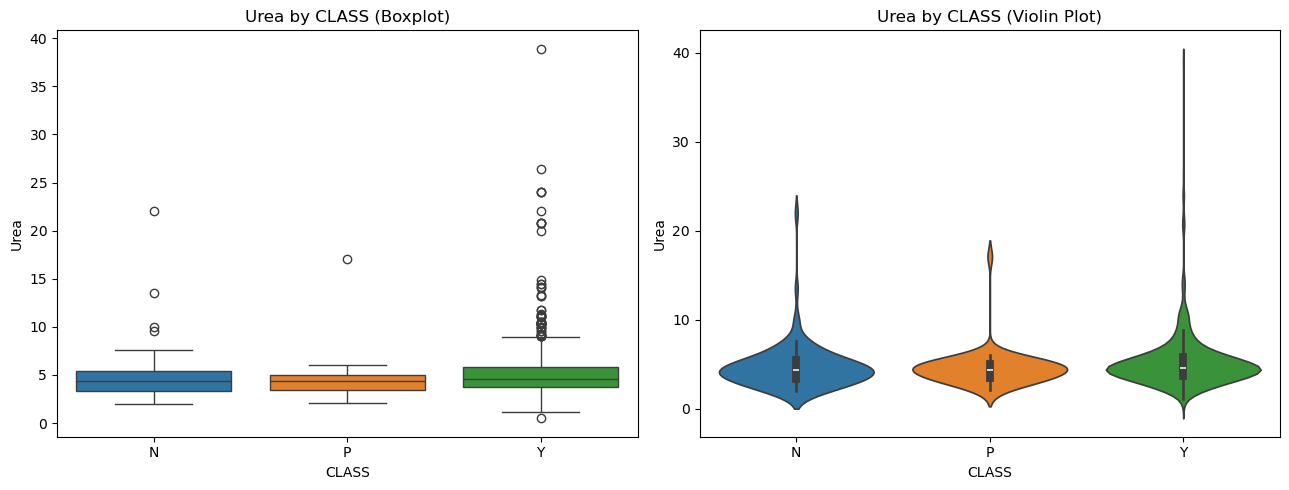

In [150]:
# Selected numerical features for visualization
selected_features = [
    ("HbA1c", "CLASS"),
    ("BMI", "CLASS"),
    ("Chol", "CLASS"),
    ("LDL", "CLASS"),
    ("Urea", "CLASS")
]

# Create folder to store the generated plots
import os
os.makedirs("figures", exist_ok=True)

# Color scheme for diabetes classes
class_colors = { "N": "#1f77b4",  "P": "#ff7f0e", "Y": "#2ca02c" }

# Generate visualizations
for feature, target in selected_features:

    if feature not in data_numeric.columns or target not in data.columns:
        continue

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # Boxplot
    sns.boxplot(
        data=data,
        x=target,
        y=feature,
        hue=target,
        palette=class_colors,
        legend=False,
        ax=ax1
    )

    ax1.set_title(f"{feature} by {target} (Boxplot)")
    ax1.set_xlabel(target)
    ax1.set_ylabel(feature)

    # Violin plot
    sns.violinplot(
        data=data,
        x=target,
        y=feature,
        hue=target,
        palette=class_colors,
        legend=False,
        ax=ax2
    )

    ax2.set_title(f"{feature} by {target} (Violin Plot)")
    ax2.set_xlabel(target)
    ax2.set_ylabel(feature)

    plt.tight_layout()

    plt.savefig(
        f"figures/{feature.lower()}_{target.lower()}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [151]:
# Calculate summary statistics for selected features by diabetes class
features = ["AGE", "BMI", "HbA1c", "Chol", "LDL", "HDL", "TG", "Urea", "Cr"]

# Keep only the features available in the dataset
available_features = data.columns.intersection(features)

# Generate summary statistics for each class
class_summary = (
    data.groupby("CLASS")[available_features].agg(["mean", "median", "std"])
)

class_summary

AGE                       Urea                          Cr  \
            mean median       std      mean median       std       mean   
CLASS                                                                     
N      44.233010   44.0  9.418592  4.680583    4.4  2.517665  62.796117   
P      43.283019   48.0  7.761783  4.511321    4.4  2.022438  66.075472   
Y      55.305687   55.0  7.548902  5.217468    4.6  3.022224  69.873223   

                            HbA1c  ...        TG       HDL                   \
      median        std      mean  ...       std      mean median       std   
CLASS                              ...                                        
N       55.0  30.016453  4.560194  ...  1.025338  1.227184    1.1  0.514342   
P       59.0  41.566374  6.003774  ...  1.059236  1.127358    1.0  0.383251   
Y       60.5  63.580116  8.878270  ...  1.432638  1.206872    1.1  0.689452   

            LDL                         BMI                   
           mean median       std       mean median       std  
CLASS                                                         
N      2.625243    2.6  0.981367  22.374757   22.0  1.415234  
P      2.493396    2.5  0.868633  23.933962   24.0  2.713991  
Y      2.615213    2.5  1.144367  30.811517   30.0  4.315068  

[3 rows x 27 columns]

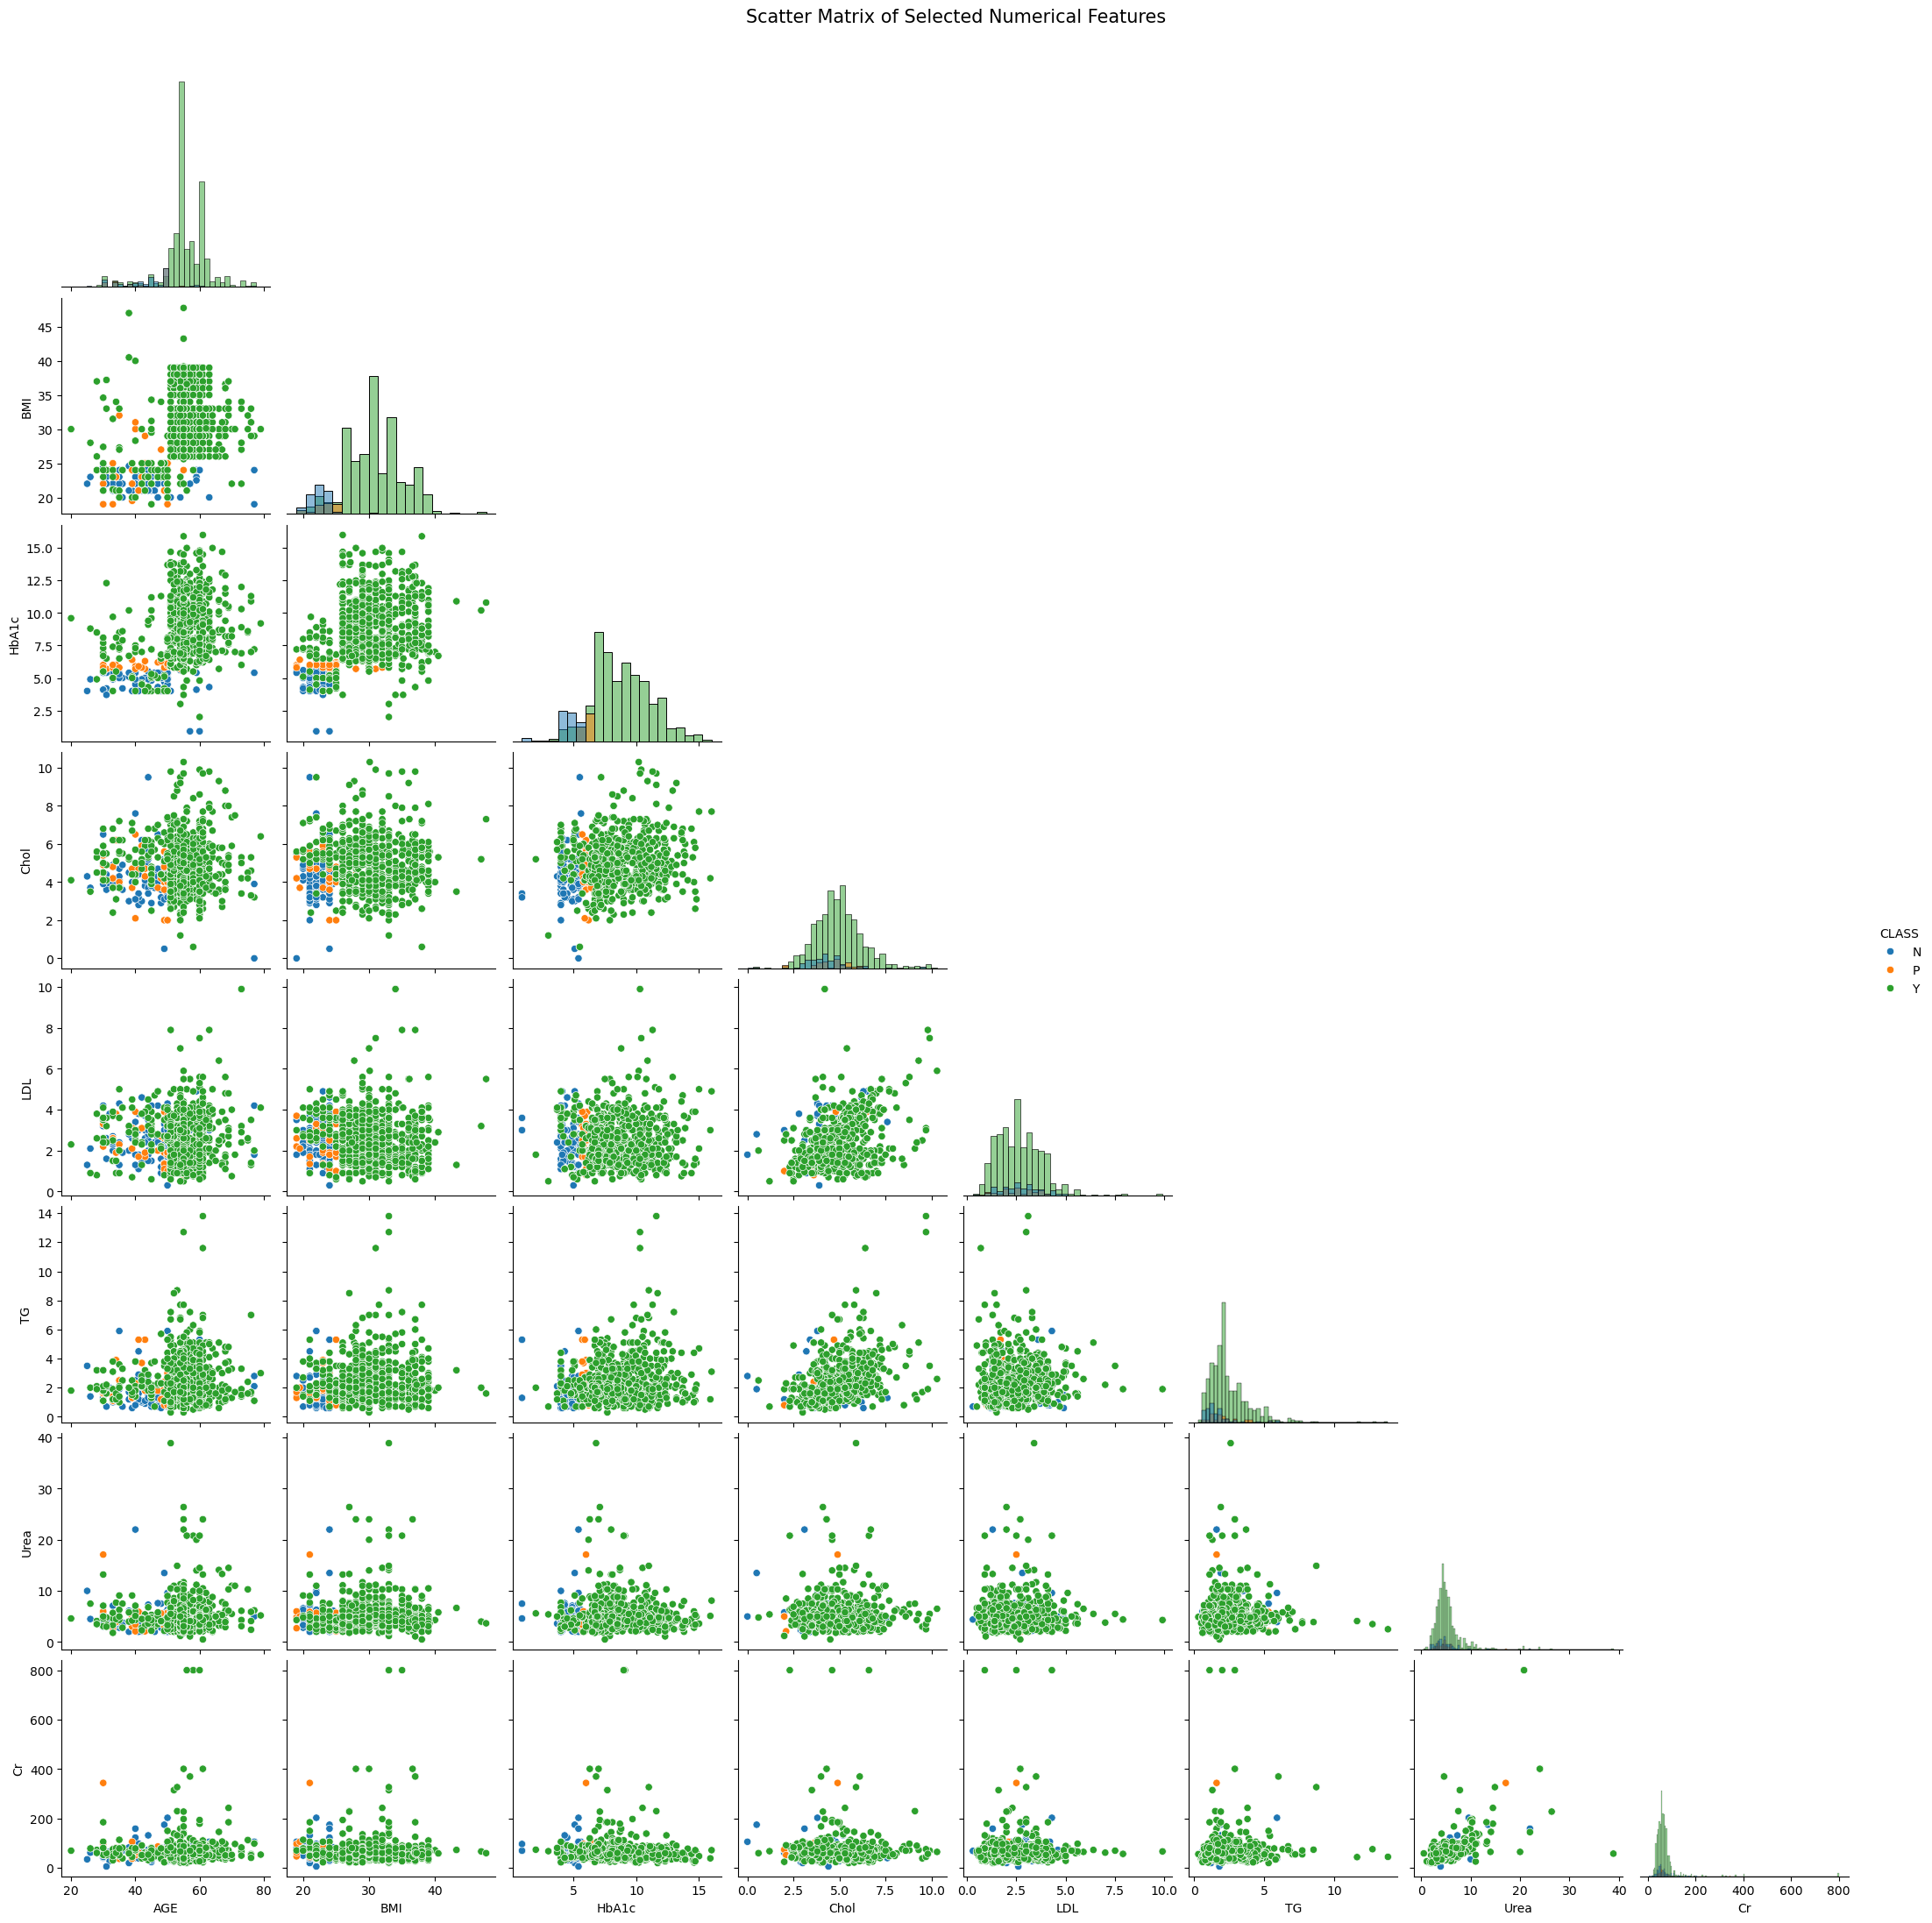

In [152]:
# Scatter matrix for selected numerical features
plot_features = ["AGE", "BMI", "HbA1c", "Chol", "LDL", "TG", "Urea", "Cr"]

# Make sure the target column is categorical
data["CLASS"] = data["CLASS"].astype("category")

# Custom colors for each class
class_colors = {"N": "#1f77b4","P": "#ff7f0e", "Y": "#2ca02c"}

pair_plot = sns.pairplot(
    data=data,
    vars=plot_features,
    hue="CLASS",
    palette=class_colors,
    diag_kind="hist",
    corner=True,
    height=2.7
)

pair_plot.fig.suptitle("Scatter Matrix of Selected Numerical Features", y=1.02, fontsize=15)

plt.show()

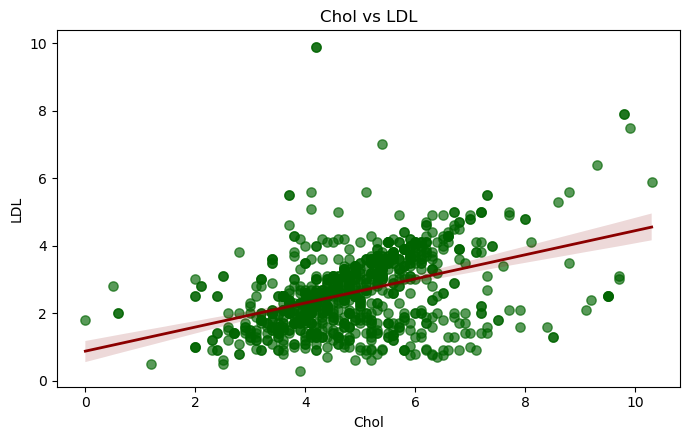

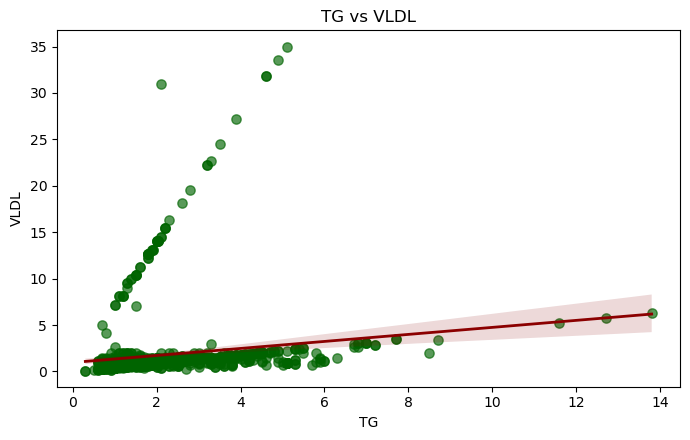

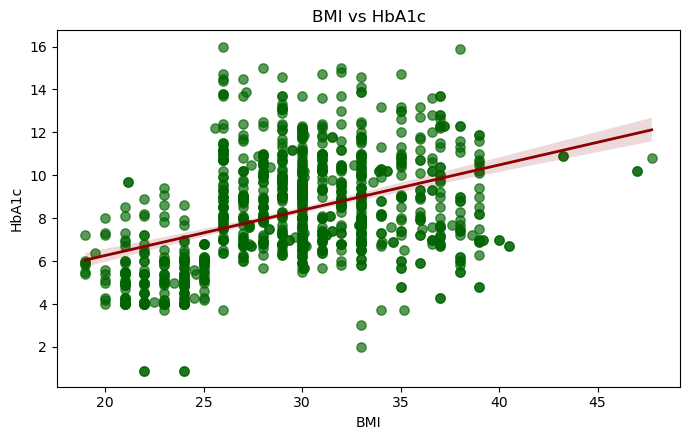

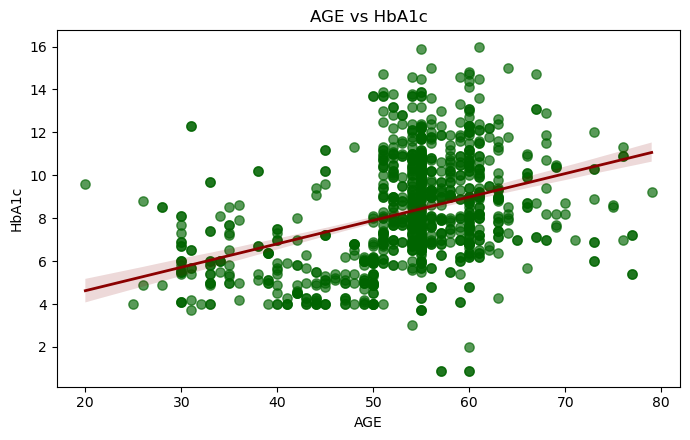

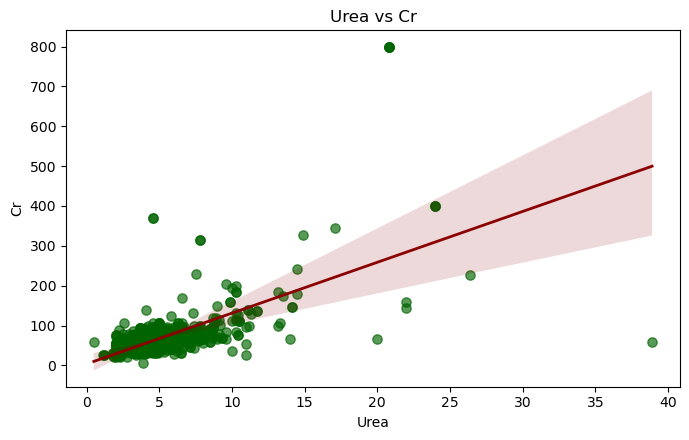

In [153]:
# Plot regression relationships between selected feature pairs
feature_pairs = [
    ("Chol", "LDL"),
    ("TG", "VLDL"),
    ("BMI", "HbA1c"),
    ("AGE", "HbA1c"),
    ("Urea", "Cr")
]

for feature_x, feature_y in feature_pairs:

    if feature_x not in data.columns or feature_y not in data.columns:
        continue

    plt.figure(figsize=(7, 4.5))

    sns.regplot(
        data=data,
        x=feature_x,
        y=feature_y,
        scatter_kws={
            "color": "darkgreen",
            "alpha": 0.65,
            "s": 45
        },
        line_kws={
            "color": "darkred",
            "linewidth": 2
        }
    )

    plt.title(f"{feature_x} vs {feature_y}")
    plt.xlabel(feature_x)
    plt.ylabel(feature_y)

    plt.tight_layout()
    plt.show()

In [175]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data["CLASS"] = encoder.fit_transform(data["CLASS"])

# Keep Gender
X = data.drop(columns=["ID", "No_Pation", "CLASS"])
y = data["CLASS"]

In [177]:
# Preprocessing pipeline: scale selected features and discretize others
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, KBinsDiscretizer

# Features to scale between 0 and 1
scaled_features = [
    "HbA1c",
    "BMI",
    "Chol",
    "LDL",
    "HDL"
]

# Features to convert into bins
binned_features = [
    "AGE",
    "Cr",
    "Urea",
    "TG",
    "VLDL"
]

# Build the preprocessing transformer
data_preprocessor = ColumnTransformer(
    transformers=[
        (
            "scaling",
            MinMaxScaler(),
            scaled_features
        ),
        (
            "binning",
            KBinsDiscretizer(
                n_bins=4,
                strategy="quantile",
                encode="ordinal"
            ),
            binned_features
        )
    ],
    remainder="passthrough"
)

# Combine preprocessing steps into one pipeline
preprocessing_pipeline = Pipeline([
    ("preprocessing", data_preprocessor)
])

preprocessing_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaling', MinMaxScaler(),
                                                  ['HbA1c', 'BMI', 'Chol',
                                                   'LDL', 'HDL']),
                                                 ('binning',
                                                  KBinsDiscretizer(encode='ordinal',
                                                                   n_bins=4),
                                                  ['AGE', 'Cr', 'Urea', 'TG',
                                                   'VLDL'])]))])

In [179]:
# Divide the dataset into training and testing subsets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("Dataset Split Summary")
print("-" * 30)
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

print("\nClass distribution in the training set:")
print(y_train.value_counts())

print("\nClass distribution in the testing set:")
print(y_test.value_counts())

Dataset Split Summary
------------------------------
Training samples : 850
Testing samples  : 150

Class distribution in the training set:
CLASS
2    717
0     88
1     45
Name: count, dtype: int64

Class distribution in the testing set:
CLASS
2    127
0     15
1      8
Name: count, dtype: int64


Decision Tree

In [180]:
from sklearn.tree import DecisionTreeClassifier

# Separate numerical and categorical columns
num_cols = [
    "AGE", "Urea", "Cr", "HbA1c", "Chol",
    "TG", "HDL", "LDL", "VLDL", "BMI"
]

cat_cols = ["Gender"]

# Build the feature transformer
feature_transformer = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), num_cols),
        ("encode", OneHotEncoder(), cat_cols)
    ]
)

# Decision Tree workflow
decision_tree_model = Pipeline([
    ("feature_transformer", feature_transformer),
    ("decision_tree", DecisionTreeClassifier(random_state=42))
])

decision_tree_model

Pipeline(steps=[('feature_transformer',
                 ColumnTransformer(transformers=[('scale', StandardScaler(),
                                                  ['AGE', 'Urea', 'Cr', 'HbA1c',
                                                   'Chol', 'TG', 'HDL', 'LDL',
                                                   'VLDL', 'BMI']),
                                                 ('encode', OneHotEncoder(),
                                                  ['Gender'])])),
                ('decision_tree', DecisionTreeClassifier(random_state=42))])

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END decision_tree__criterion=gini, decision_tree__max_depth=5, decision_tree__min_samples_leaf=1, decision_tree__min_samples_split=2; total time=   0.0s
[CV] END decision_tree__criterion=gini, decision_tree__max_depth=5, decision_tree__min_samples_leaf=1, decision_tree__min_samples_split=2; total time=   0.0s
[CV] END decision_tree__criterion=gini, decision_tree__max_depth=5, decision_tree__min_samples_leaf=1, decision_tree__min_samples_split=2; total time=   0.0s
[CV] END decision_tree__criterion=gini, decision_tree__max_depth=5, decision_tree__min_samples_leaf=1, decision_tree__min_samples_split=2; total time=   0.0s
[CV] END decision_tree__criterion=gini, decision_tree__max_depth=5, decision_tree__min_samples_leaf=1, decision_tree__min_samples_split=2; total time=   0.0s
[CV] END decision_tree__criterion=gini, decision_tree__max_depth=5, decision_tree__min_samples_leaf=1, decision_tree__min_samples_split=5; total tim

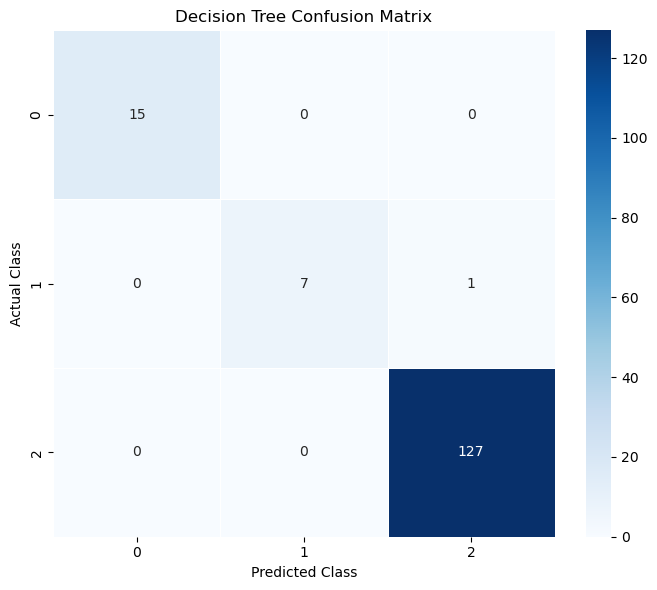

In [181]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# Features and target
X = data.drop("CLASS", axis=1)
y = data["CLASS"]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Numerical & categorical columns
num_cols = [
    "AGE", "Urea", "Cr", "HbA1c",
    "Chol", "TG", "HDL",
    "LDL", "VLDL", "BMI"
]

cat_cols = ["Gender"]

# Preprocessing
feature_transformer = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), num_cols),
        ("encode", OneHotEncoder(), cat_cols)
    ]
)

# Decision Tree Pipeline
decision_tree_model = Pipeline([
    ("feature_transformer", feature_transformer),
    ("decision_tree", DecisionTreeClassifier(random_state=42))
])

# Smaller parameter grid
search_parameters = {
    "decision_tree__max_depth": [5, 10, None],
    "decision_tree__min_samples_split": [2, 5],
    "decision_tree__min_samples_leaf": [1, 2],
    "decision_tree__criterion": ["gini", "entropy"]
}

# Grid Search
dt_search = GridSearchCV(
    estimator=decision_tree_model,
    param_grid=search_parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=1, 
    verbose=2
)

# Train model
dt_search.fit(X_train, y_train)

# Best Results
print("\nBest Hyperparameters")
print("-" * 40)
print(dt_search.best_params_)

print(f"\nBest Cross Validation Accuracy: {dt_search.best_score_:.4f}")

# Predictions
predictions = dt_search.predict(X_test)

precision = precision_score(
    y_test,
    predictions,
    average="weighted"
)

recall = recall_score(
    y_test,
    predictions,
    average="weighted"
)

print(f"\nWeighted Precision : {precision:.4f}")
print(f"Weighted Recall    : {recall:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, predictions)

print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    xticklabels=dt_search.best_estimator_.classes_,
    yticklabels=dt_search.best_estimator_.classes_
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

# Save Best Model
optimal_decision_tree = dt_search.best_estimator_

Feature Importance Ranking
-----------------------------------
     Feature     Score
0      HbA1c  0.725227
1        AGE  0.109801
2       Chol  0.069970
3        BMI  0.065407
4         TG  0.029595
5       Urea  0.000000
6         Cr  0.000000
7        HDL  0.000000
8        LDL  0.000000
9       VLDL  0.000000
10  Gender_0  0.000000
11  Gender_1  0.000000


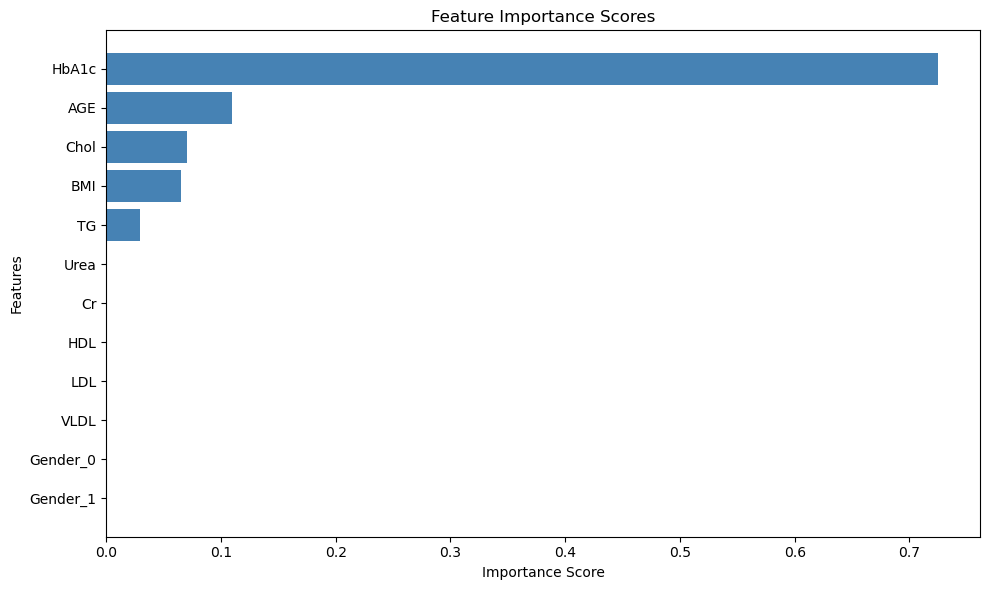

In [182]:
# Retrieve feature importance scores from the trained Decision Tree

tree_model = optimal_decision_tree.named_steps["decision_tree"]
importance_scores = tree_model.feature_importances_

# Retrieve feature names after preprocessing
transformer = optimal_decision_tree.named_steps["feature_transformer"]

encoded_gender = transformer.named_transformers_["encode"].get_feature_names_out(cat_cols)

feature_names = num_cols + list(encoded_gender)

# Create a summary table
importance_table = (
    pd.DataFrame({
        "Feature": feature_names,
        "Score": importance_scores
    })
    .sort_values(by="Score", ascending=False)
    .reset_index(drop=True)
)

print("Feature Importance Ranking")
print("-" * 35)
print(importance_table)

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    importance_table["Feature"],
    importance_table["Score"],
    color="steelblue"
)

plt.title("Feature Importance Scores")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

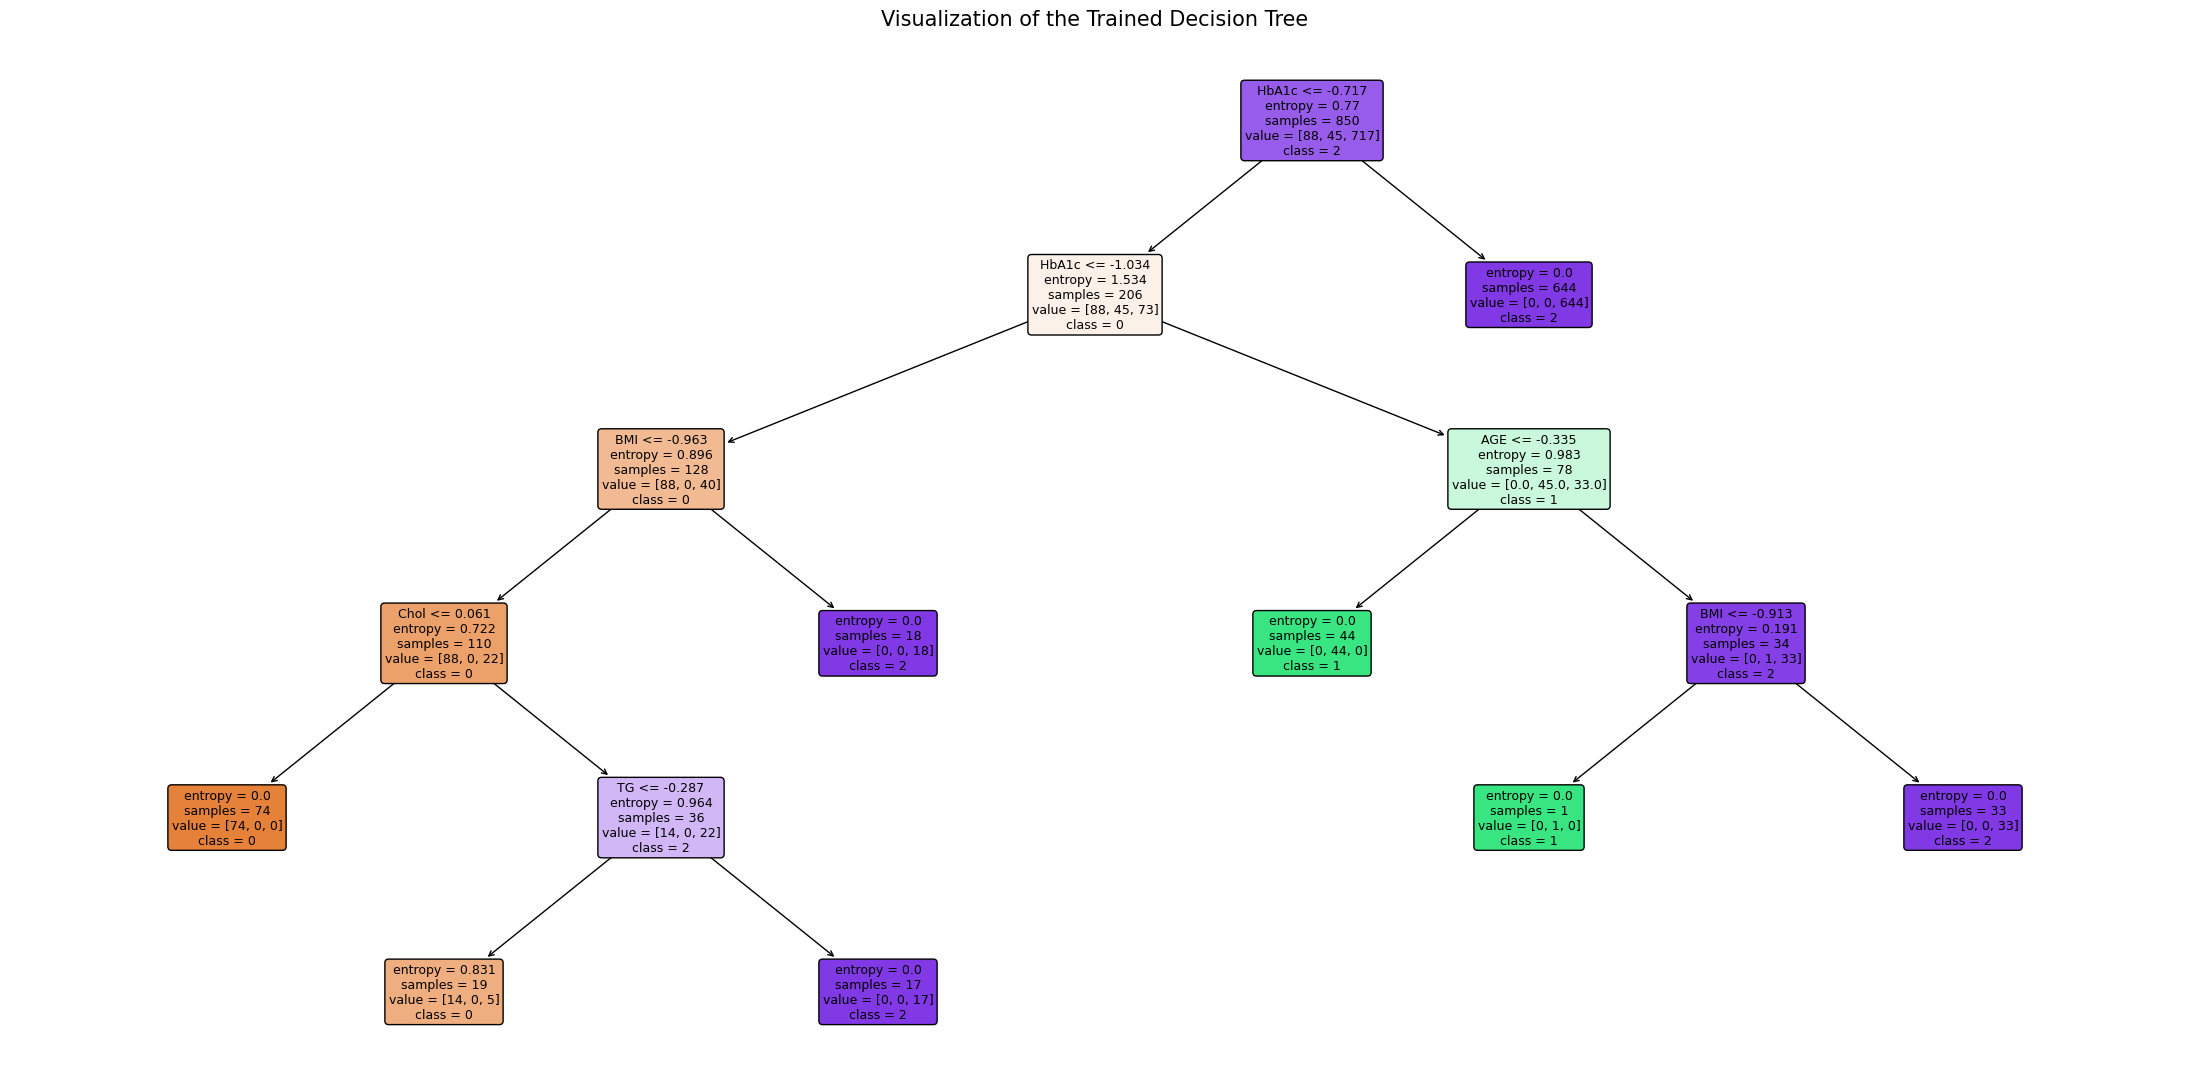

In [183]:
from sklearn.tree import plot_tree

# Display the trained Decision Tree model
plt.figure(figsize=(22, 11))

plot_tree(
    decision_tree=tree_model,
    feature_names=feature_names,
    class_names=[str(label) for label in optimal_decision_tree.classes_],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=9
)

plt.title("Visualization of the Trained Decision Tree", fontsize=15)

plt.tight_layout()
plt.show()

Logistic Regression

In [184]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, precision_score, recall_score

# Separate the input features by data type
num_cols = [
    "AGE", "Urea", "Cr", "HbA1c", "Chol",
    "TG", "HDL", "LDL", "VLDL", "BMI"
]

cat_cols = ["Gender"]

# Apply scaling to numerical features and one-hot encoding to categorical features
feature_transformer = ColumnTransformer(
    transformers=[
        ("scaling", StandardScaler(), num_cols),
        ("encoding", OneHotEncoder(), cat_cols)
    ]
)

# Create the Logistic Regression pipeline
logistic_model = Pipeline([
    ("feature_transformer", feature_transformer),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model

Pipeline(steps=[('feature_transformer',
                 ColumnTransformer(transformers=[('scaling', StandardScaler(),
                                                  ['AGE', 'Urea', 'Cr', 'HbA1c',
                                                   'Chol', 'TG', 'HDL', 'LDL',
                                                   'VLDL', 'BMI']),
                                                 ('encoding', OneHotEncoder(),
                                                  ['Gender'])])),
                ('logistic_regression',
                 LogisticRegression(max_iter=1000, random_state=42))])

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END logistic_regression__C=0.01, logistic_regression__penalty=l2, logistic_regression__solver=lbfgs; total time=   0.0s
[CV] END logistic_regression__C=0.01, logistic_regression__penalty=l2, logistic_regression__solver=lbfgs; total time=   0.0s
[CV] END logistic_regression__C=0.01, logistic_regression__penalty=l2, logistic_regression__solver=lbfgs; total time=   0.0s
[CV] END logistic_regression__C=0.01, logistic_regression__penalty=l2, logistic_regression__solver=lbfgs; total time=   0.0s
[CV] END logistic_regression__C=0.01, logistic_regression__penalty=l2, logistic_regression__solver=lbfgs; total time=   0.0s
[CV] END logistic_regression__C=0.1, logistic_regression__penalty=l2, logistic_regression__solver=lbfgs; total time=   0.0s
[CV] END logistic_regression__C=0.1, logistic_regression__penalty=l2, logistic_regression__solver=lbfgs; total time=   0.0s
[CV] END logistic_regression__C=0.1, logistic_regression__penalty=l

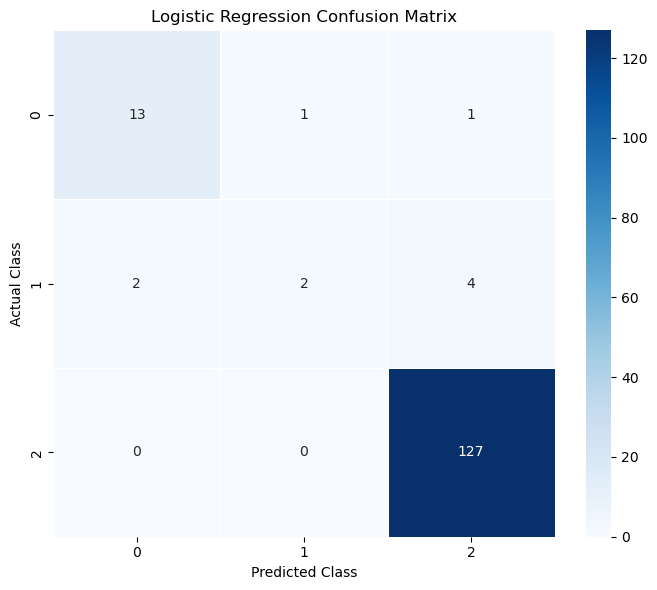

In [185]:
# Hyperparameter tuning for Logistic Regression

search_space = {
    "logistic_regression__C": [0.01, 0.1, 1, 10, 100],
    "logistic_regression__penalty": ["l2"],
    "logistic_regression__solver": ["lbfgs"]
}

# Perform grid search with cross-validation
lr_search = GridSearchCV(
    estimator=logistic_model,
    param_grid=search_space,
    scoring="accuracy",
    cv=5,
    n_jobs=1,    
    verbose=2
)

# Train all parameter combinations
lr_search.fit(X_train, y_train)

# Display the best model configuration
print("Optimal Hyperparameters")
print("-" * 30)
print(lr_search.best_params_)

print(f"\nBest Cross-Validation Accuracy: {lr_search.best_score_:.4f}")

# Make predictions on the test data
lr_predictions = lr_search.predict(X_test)

# Calculate evaluation metrics
weighted_precision = precision_score(
    y_test,
    lr_predictions,
    average="weighted"
)

weighted_recall = recall_score(
    y_test,
    lr_predictions,
    average="weighted"
)

print(f"\nWeighted Precision : {weighted_precision:.4f}")
print(f"Weighted Recall    : {weighted_recall:.4f}")

# Compute confusion matrix
conf_matrix = confusion_matrix(y_test, lr_predictions)

print("\nConfusion Matrix")
print(conf_matrix)

# Visualize confusion matrix
plt.figure(figsize=(7, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=lr_search.best_estimator_.classes_,
    yticklabels=lr_search.best_estimator_.classes_,
    linewidths=0.5
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

# Store the best-performing model
best_logistic_model = lr_search.best_estimator_

Logistic Regression Feature Coefficients
---------------------------------------------
     Feature  Coefficient
0   Gender_0     0.229608
1       VLDL     0.063970
2       Urea     0.060960
3        LDL     0.039846
4        HDL    -0.020384
5        AGE    -0.163923
6         Cr    -0.177286
7   Gender_1    -0.343737
8       Chol    -0.707297
9         TG    -0.730498
10       BMI    -2.617214
11     HbA1c    -2.969749


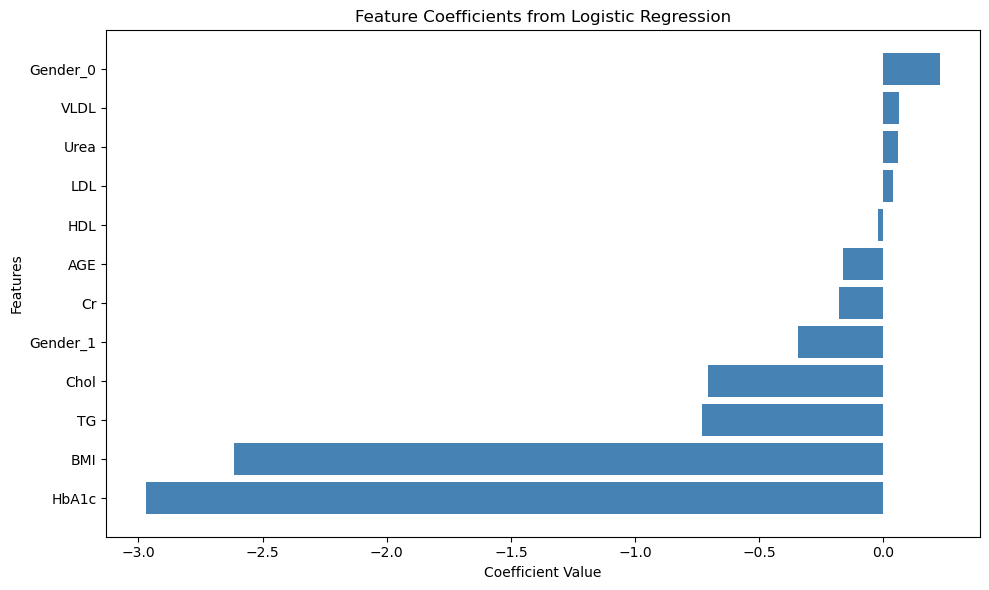

In [186]:
# Extract coefficient values from the trained Logistic Regression model

logistic_classifier = best_logistic_model.named_steps["logistic_regression"]
transformer = best_logistic_model.named_steps["feature_transformer"]
encoded_features = transformer.named_transformers_["encoding"].get_feature_names_out(cat_cols)
feature_list = num_cols + list(encoded_features)
coefficient_values = logistic_classifier.coef_[0]

# Create a summary table of feature coefficients
coefficient_table = (
    pd.DataFrame({
        "Feature": feature_list,
        "Coefficient": coefficient_values
    })
    .sort_values(by="Coefficient", ascending=False)
    .reset_index(drop=True)
)

print("Logistic Regression Feature Coefficients")
print("-" * 45)
print(coefficient_table)

# Plot the coefficients
plt.figure(figsize=(10, 6))

plt.barh(
    coefficient_table["Feature"],
    coefficient_table["Coefficient"],
    color="steelblue"
)

plt.title("Feature Coefficients from Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

SVM

In [187]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate numerical and categorical features
num_cols = [
    "AGE", "Urea", "Cr", "HbA1c", "Chol",
    "TG", "HDL", "LDL", "VLDL", "BMI"
]

cat_cols = ["Gender"]

# Preprocess the data before training
feature_transformer = ColumnTransformer(
    transformers=[
        ("scaling", StandardScaler(), num_cols),
        ("encoding", OneHotEncoder(), cat_cols)
    ]
)

# Support Vector Machine pipeline
svm_model = Pipeline([
    ("feature_transformer", feature_transformer),
    ("svm_classifier", SVC(random_state=42))
])

svm_model

Pipeline(steps=[('feature_transformer',
                 ColumnTransformer(transformers=[('scaling', StandardScaler(),
                                                  ['AGE', 'Urea', 'Cr', 'HbA1c',
                                                   'Chol', 'TG', 'HDL', 'LDL',
                                                   'VLDL', 'BMI']),
                                                 ('encoding', OneHotEncoder(),
                                                  ['Gender'])])),
                ('svm_classifier', SVC(random_state=42))])

In [188]:
# Hyperparameter optimization for the Support Vector Machine

from sklearn.model_selection import GridSearchCV

svm_parameters = {
    "svm_classifier__C": [0.1, 1, 10],
    "svm_classifier__kernel": ["linear", "rbf"],
    "svm_classifier__gamma": ["scale", "auto"]
}

svm_search = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_parameters,
    scoring="accuracy",
    cv=5,
    n_jobs=1,
    verbose=2
)

# Train and evaluate all parameter combinations
svm_search.fit(X_train, y_train)

print("Optimal SVM Parameters")
print("-" * 30)
print(svm_search.best_params_)

print(f"\nBest Cross-Validation Accuracy: {svm_search.best_score_:.4f}")

# Save the best model
optimal_svm_model = svm_search.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END svm_classifier__C=0.1, svm_classifier__gamma=scale, svm_classifier__kernel=linear; total time=   0.0s
[CV] END svm_classifier__C=0.1, svm_classifier__gamma=scale, svm_classifier__kernel=linear; total time=   0.0s
[CV] END svm_classifier__C=0.1, svm_classifier__gamma=scale, svm_classifier__kernel=linear; total time=   0.0s
[CV] END svm_classifier__C=0.1, svm_classifier__gamma=scale, svm_classifier__kernel=linear; total time=   0.0s
[CV] END svm_classifier__C=0.1, svm_classifier__gamma=scale, svm_classifier__kernel=linear; total time=   0.0s
[CV] END svm_classifier__C=0.1, svm_classifier__gamma=scale, svm_classifier__kernel=rbf; total time=   0.1s
[CV] END svm_classifier__C=0.1, svm_classifier__gamma=scale, svm_classifier__kernel=rbf; total time=   0.1s
[CV] END svm_classifier__C=0.1, svm_classifier__gamma=scale, svm_classifier__kernel=rbf; total time=   0.1s
[CV] END svm_classifier__C=0.1, svm_classifier__gamma=scale,

Support Vector Machine Performance
----------------------------------------
Weighted Precision : 0.9481
Weighted Recall    : 0.9533

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.93      0.90        15
           1       0.75      0.38      0.50         8
           2       0.97      0.99      0.98       127

    accuracy                           0.95       150
   macro avg       0.86      0.77      0.79       150
weighted avg       0.95      0.95      0.95       150


Confusion Matrix
[[ 14   0   1]
 [  2   3   3]
 [  0   1 126]]


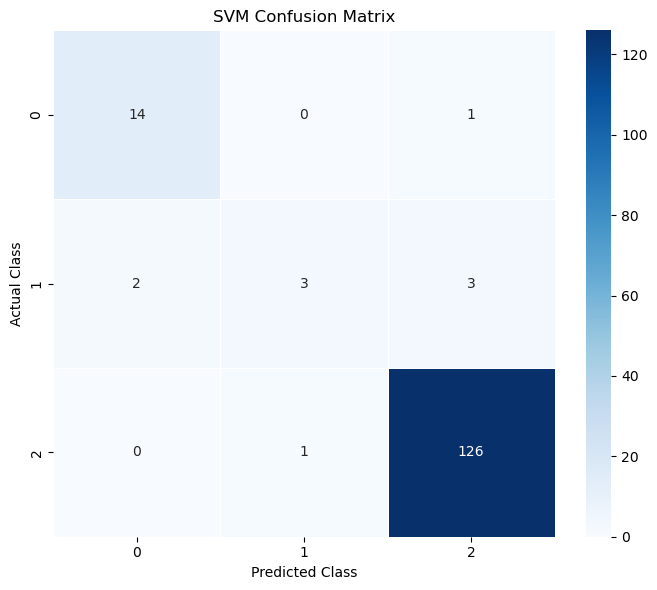

In [189]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions using the optimized SVM model
svm_predictions = optimal_svm_model.predict(X_test)

# Compute evaluation metrics
weighted_precision = precision_score(
    y_test,
    svm_predictions,
    average="weighted"
)

weighted_recall = recall_score(
    y_test,
    svm_predictions,
    average="weighted"
)

print("Support Vector Machine Performance")
print("-" * 40)
print(f"Weighted Precision : {weighted_precision:.4f}")
print(f"Weighted Recall    : {weighted_recall:.4f}")

print("\nClassification Report")
print(classification_report(y_test, svm_predictions))

# Build the confusion matrix
conf_matrix = confusion_matrix(y_test, svm_predictions)

print("\nConfusion Matrix")
print(conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(7, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    xticklabels=optimal_svm_model.classes_,
    yticklabels=optimal_svm_model.classes_
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

Random Forest

In [191]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define numerical and categorical input features
num_cols = [
    "AGE", "Urea", "Cr", "HbA1c", "Chol",
    "TG", "HDL", "LDL", "VLDL", "BMI"
]

cat_cols = ["Gender"]

# Data preprocessing
feature_transformer = ColumnTransformer(
    transformers=[
        ("scaling", StandardScaler(), num_cols),
        ("encoding", OneHotEncoder(), cat_cols)
    ]
)

# Random Forest classification pipeline
random_forest_model = Pipeline([
    ("feature_transformer", feature_transformer),
    ("random_forest", RandomForestClassifier(random_state=42))
])

random_forest_model

Pipeline(steps=[('feature_transformer',
                 ColumnTransformer(transformers=[('scaling', StandardScaler(),
                                                  ['AGE', 'Urea', 'Cr', 'HbA1c',
                                                   'Chol', 'TG', 'HDL', 'LDL',
                                                   'VLDL', 'BMI']),
                                                 ('encoding', OneHotEncoder(),
                                                  ['Gender'])])),
                ('random_forest', RandomForestClassifier(random_state=42))])

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Random Forest Parameters
-----------------------------------
{'random_forest__criterion': 'entropy', 'random_forest__max_depth': 5, 'random_forest__max_features': None, 'random_forest__min_samples_leaf': 4, 'random_forest__n_estimators': 100}

Best Cross-Validation Accuracy: 0.9894

Weighted Precision : 0.9934
Weighted Recall    : 0.9933

Confusion Matrix
[[ 15   0   0]
 [  0   7   1]
 [  0   0 127]]


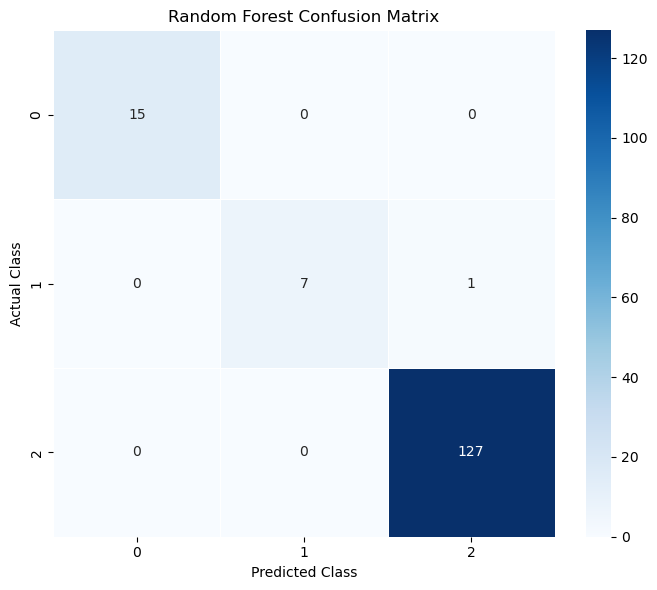

In [192]:
# Hyperparameter tuning for the Random Forest model

rf_parameters = {
    "random_forest__n_estimators": [50, 100],
    "random_forest__max_depth": [3, 5, 7, None],
    "random_forest__min_samples_leaf": [1, 2, 4],
    "random_forest__criterion": ["entropy"],
    "random_forest__max_features": ["sqrt", "log2", None]
}

rf_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=rf_parameters,
    cv=5,
    scoring="accuracy",
    n_jobs=1,    
    verbose=1
)

# Train the Random Forest model
rf_search.fit(X_train, y_train)

# Display the optimal hyperparameters
print("Best Random Forest Parameters")
print("-" * 35)
print(rf_search.best_params_)

print(f"\nBest Cross-Validation Accuracy: {rf_search.best_score_:.4f}")

# Predict the test set labels
rf_predictions = rf_search.predict(X_test)

# Calculate evaluation metrics
rf_precision = precision_score(
    y_test,
    rf_predictions,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_predictions,
    average="weighted"
)

print(f"\nWeighted Precision : {rf_precision:.4f}")
print(f"Weighted Recall    : {rf_recall:.4f}")

# Create confusion matrix
rf_confusion = confusion_matrix(y_test, rf_predictions)

print("\nConfusion Matrix")
print(rf_confusion)

# Plot confusion matrix
plt.figure(figsize=(7, 6))

sns.heatmap(
    rf_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    xticklabels=rf_search.best_estimator_.classes_,
    yticklabels=rf_search.best_estimator_.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

# Store the optimized Random Forest model
best_random_forest = rf_search.best_estimator_

In [193]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbalancedPipeline

# Encode the Gender column
data["Gender"] = data["Gender"].replace({"M": 1, "F": 0})

# Select features
selected_columns = [
    "AGE", "Urea", "Cr", "HbA1c", "Chol",
    "TG", "HDL", "LDL", "VLDL", "BMI", "Gender"
]

X = data[selected_columns]
y = data["CLASS"]

# Create the pipeline
naive_bayes_model = ImbalancedPipeline([
    ("smote", SMOTE(random_state=42)),
    ("gaussian_nb", GaussianNB())
])

# Cross-validation strategy
cross_validator = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluate the model
cv_results = cross_validate(
    estimator=naive_bayes_model,
    X=X,
    y=y,
    cv=cross_validator,
    scoring=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro"
    ]
)

print("Naive Bayes Cross-Validation Results")
print("-" * 45)

print(f"Accuracy : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"Precision: {cv_results['test_precision_macro'].mean():.4f} ± {cv_results['test_precision_macro'].std():.4f}")
print(f"Recall   : {cv_results['test_recall_macro'].mean():.4f} ± {cv_results['test_recall_macro'].std():.4f}")
print(f"F1 Score : {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")

Naive Bayes Cross-Validation Results
---------------------------------------------
Accuracy : 0.9250 ± 0.0164
Precision: 0.8012 ± 0.0303
Recall   : 0.8867 ± 0.0780
F1 Score : 0.8349 ± 0.0437


KNN

In [ ]:
import pandas as pd

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------
# Select numerical features
# ---------------------------------------
numeric_features = [
    "AGE", "Urea", "Cr", "HbA1c",
    "Chol", "TG", "HDL",
    "LDL", "VLDL", "BMI"
]

# Use ONLY the training and testing sets
X_train_knn = X_train[numeric_features]
X_test_knn = X_test[numeric_features]

# ---------------------------------------
# Build KNN pipeline
# ---------------------------------------
knn_pipeline = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("knn_classifier", KNeighborsClassifier())
])

# ---------------------------------------
# Hyperparameter search space
# ---------------------------------------
param_grid = {
    "knn_classifier__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "knn_classifier__weights": ["uniform", "distance"],
    "knn_classifier__metric": ["euclidean", "manhattan"]
}

# ---------------------------------------
# Cross-validation
# ---------------------------------------
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ---------------------------------------
# Grid Search
# ---------------------------------------
grid = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)

# Train ONLY on training data
grid.fit(X_train_knn, y_train)

print("\n===== Best Hyperparameters =====")
print(grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{grid.best_score_:.4f}")

# ---------------------------------------
# Best model
# ---------------------------------------
best_knn_model = grid.best_estimator_

# ---------------------------------------
# Test set predictions
# ---------------------------------------
knn_predictions = best_knn_model.predict(X_test_knn)

# ---------------------------------------
# Evaluation
# ---------------------------------------
accuracy = accuracy_score(y_test, knn_predictions)
precision = precision_score(
    y_test,
    knn_predictions,
    average="weighted"
)
recall = recall_score(
    y_test,
    knn_predictions,
    average="weighted"
)
f1 = f1_score(
    y_test,
    knn_predictions,
    average="weighted"
)

print("\n===== Test Set Performance =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report")
print(classification_report(y_test, knn_predictions))

# ---------------------------------------
# Confusion Matrix
# ---------------------------------------
cm = confusion_matrix(y_test, knn_predictions)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_knn_model.classes_,
    yticklabels=best_knn_model.classes_
)

plt.title("K-Nearest Neighbors Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

Fitting 5 folds for each of 28 candidates, totalling 140 fits
[CV] END knn_classifier__metric=euclidean, knn_classifier__n_neighbors=3, knn_classifier__weights=uniform; total time=   0.0s
[CV] END knn_classifier__metric=euclidean, knn_classifier__n_neighbors=3, knn_classifier__weights=uniform; total time=   0.0s
[CV] END knn_classifier__metric=euclidean, knn_classifier__n_neighbors=3, knn_classifier__weights=uniform; total time=   0.0s
[CV] END knn_classifier__metric=euclidean, knn_classifier__n_neighbors=3, knn_classifier__weights=uniform; total time=   0.0s
[CV] END knn_classifier__metric=euclidean, knn_classifier__n_neighbors=3, knn_classifier__weights=uniform; total time=   0.0s
[CV] END knn_classifier__metric=euclidean, knn_classifier__n_neighbors=3, knn_classifier__weights=distance; total time=   0.0s
[CV] END knn_classifier__metric=euclidean, knn_classifier__n_neighbors=3, knn_classifier__weights=distance; total time=   0.0s
[CV] END knn_classifier__metric=euclidean, knn_classif